In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
with open("config.json") as f:
    config = json.load(f)

# %%
strategies = config["strategies"]
strategy = strategies[-1]

# Load the DataFrame containing scan information
df = pd.read_csv('data/func_scans_table_outliers_ses-PSI_PPLSDI.csv')
df = df[df['task']==config["task"]]
df = df[df['include_scan_coil_numvols']]
df = df[df['include_manual_qc']]
df = df[df['ratio_outliers_fd0.5_std_dvars1.5'] < config["ratio_outliers_fd0.5_std_dvars1.5"]]

data = []
fs = []
stds = []
scanners = []
for idx, scan in df.iterrows():
    image_path = 'data/denoised/'+strategy+'/' + scan.subject + '/' + scan.session + '/func/'
    image_file = os.path.basename(scan.preproc_filename_cifti.replace('.dtseries.nii', '_denoised_parcellated_schaefertian232.txt'))
    data_scan = np.loadtxt(image_path+'/'+image_file)
    data.append(data_scan.T)
    fs.append(1 / scan.tr)
    stds.append(np.std(data_scan))
    scanners.append(scan.scanner)
fs = np.array(fs)
stds = np.array(stds)
scanners = np.array(scanners)

In [41]:
# subject to color map
subject_ids = df['subject'].unique()
colors = plt.cm.get_cmap('tab20', len(subject_ids))
subject_color_map = {subject_id: colors(i) for i, subject_id in enumerate(subject_ids)}

# fs to color map
scanner_unique = np.unique(scanners)
scanner_colors = plt.cm.get_cmap('viridis', len(scanner_unique))
scanner_color_map = {f: scanner_colors(i) for i, f in enumerate(scanner_unique)}

/tmp/ipykernel_53386/2182074705.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(subject_ids))
/tmp/ipykernel_53386/2182074705.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  scanner_colors = plt.cm.get_cmap('viridis', len(scanner_unique))


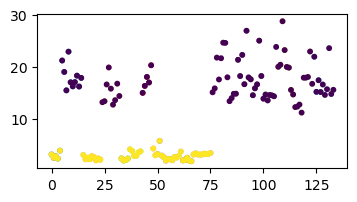

In [42]:
# plot stds of each scan colored by subject
plt.figure(figsize=(4, 2))
plt.scatter(range(len(stds)), stds, c=[subject_color_map[scan.subject] for idx, scan in df.iterrows()],s=10)
plt.scatter(range(len(stds)), stds, c=[scanner_color_map[scan.scanner] for idx, scan in df.iterrows()],s=10)

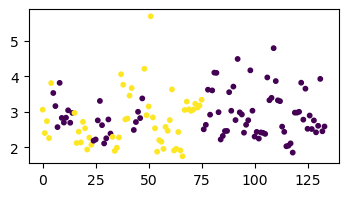

In [45]:
stds2 = stds.copy()
stds2[fs==1.25] /= 6
plt.figure(figsize=(4, 2))
plt.scatter(range(len(stds)), stds2, c=[scanner_color_map[scan.scanner] for idx, scan in df.iterrows()],s=10)

(1.5, 6.0)

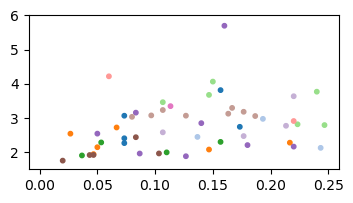

In [22]:
# plot stds of each scan colored by subject
plt.figure(figsize=(4, 2))
plt.scatter(df['ratio_outliers_fd0.5_std_dvars1.5'], stds, c=[subject_color_map[scan.subject] for idx, scan in df.iterrows()],s=10)
plt.ylim(1.5,6)

In [50]:
np.mean(np.concatenate(data,axis=1),axis=1)

array([ 9.18374859e-15,  2.90316733e-14, -5.91598402e-16,  5.21904050e-15,
        1.13875535e-15,  8.61586748e-15,  7.85068388e-15,  1.01912455e-14,
       -1.75507960e-14,  5.11686745e-15, -1.55027802e-15,  1.62824251e-14,
        8.99396959e-15,  1.96144932e-14, -6.92108967e-15,  2.64294732e-14,
       -1.28895185e-14, -1.09819846e-14, -1.30681302e-14, -1.03962504e-14,
       -3.64042536e-15,  1.34646547e-14, -9.47520450e-16,  3.88360081e-15,
        1.19445357e-15, -5.27262401e-15, -2.94332324e-14, -1.10335184e-14,
        3.01677690e-16, -8.18752473e-15,  4.30119107e-15,  1.90240579e-15,
       -1.92479976e-14, -3.04035511e-14, -1.06199461e-14, -6.70168032e-15,
        2.18138735e-14,  4.94948974e-14,  4.14309206e-15, -1.56633680e-14,
       -1.46170581e-14, -4.91092718e-15,  2.23821938e-14,  8.09062219e-15,
        4.82261666e-15,  2.12307176e-15, -8.03352501e-15, -8.61695737e-16,
       -2.65989916e-14,  1.20944850e-14,  4.12342525e-15,  2.42686294e-14,
        5.63650063e-15,  